In [26]:
import pandas as pd 
import numpy as np
df = pd.read_csv(r'Stress dataset.csv')

print(df.head())

   gender  age  stress_experience  heartbeat_palpitations  anxiety_tension  \
0       1   20                  1                       2                2   
1       0   19                  4                       5                5   
2       0   21                  4                       2                3   
3       0   20                  1                       3                2   
4       0   19                  4                       3                3   

   sleep_problems  restlessness  headaches  irritability  \
0               4             3          1             4   
1               4             4          5             4   
2               3             4          4             1   
3               1             3          1             5   
4               2             3          4             2   

   concentration_problems  ...  professor_difficulties  work_environment  \
0                       5  ...                       2                 3   
1                 

In [27]:

x = df[['stress_experience', 'heartbeat_palpitations', 'anxiety_tension', 'sleep_problems', 'restlessness', 'irritability', 'sadness_low_mood', 'loneliness_isolation', 'concentration_problems']]
y = df['stress_type']
print(x, y)

      stress_experience  heartbeat_palpitations  anxiety_tension  \
0                     1                       2                2   
1                     4                       5                5   
2                     4                       2                3   
3                     1                       3                2   
4                     4                       3                3   
...                 ...                     ...              ...   
1995                  3                       2                2   
1996                  3                       4                4   
1997                  4                       3                2   
1998                  4                       2                1   
1999                  3                       4                2   

      sleep_problems  restlessness  irritability  sadness_low_mood  \
0                  4             3             4                 5   
1                  4             4         

In [28]:
# gender,age,stress_experience,heartbeat_palpitations,anxiety_tension,sleep_problems,restlessness,headaches,irritability,concentration_problems,sadness_low_mood,health_issues,loneliness_isolation,academic_overload,peer_competition,relationship_stress,professor_difficulties,work_environment,lack_relaxation_time,home_environment,low_academic_confidence,subject_confidence,academic_conflicts,class_attendance,weight_changes,stress_type

In [29]:
from sklearn.model_selection import train_test_split
# Train-Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=47)

In [30]:
# from sklearn.linear_model import LogisticRegression
# # Model Training
# model = LogisticRegression(max_iter=200)
# model.fit(x_train, y_train)

In [31]:
# from sklearn.tree import DecisionTreeClassifier

# df= DecisionTreeClassifier()

# df.fit(x_train, y_train) 

In [32]:

from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
# from sklearn.svm import SVC

# model = SVC(kernel='rbf', random_state=1)

# # Ensure y is 1D
# y_train = y_train.ravel()

# model.fit(x_train, y_train)


In [34]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
# from math import sqrt
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# print('Mean absolute error: %.2f' % mean_absolute_error(y_test, y_pred))
# print('Mean squared error: %.2f' % mean_squared_error(y_test, y_pred))
# print('Root Mean squared error: %.2f' % sqrt(mean_squared_error(y_test, y_pred)))
# print('R2-score: %.2f' % r2_score(y_test, y_pred))


In [36]:
# import xgboost as XGBoost
# from sklearn.metrics import accuracy_score, classification_report

# # XGBoost Model
# print("Training XGBoost classifier...")
# model_xgb = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=47)
# model_xgb.fit(x_train, y_train)

# # Make predictions
# y_pred_xgb = model_xgb.predict(x_test)

# # Evaluate
# accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
# print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred_xgb))

In [37]:
from sklearn.metrics import accuracy_score
# Model Evaluation
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f' Accuracy Score: {accuracy: .2f}')

 Accuracy Score:  0.98


In [38]:
# # !pip install shap

# import shap
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.ensemble import RandomForestClassifier

# # Load dataset
# df = pd.read_csv("Stress.csv")

# # Features and target
# X = df.drop("stress_type", axis=1)
# y = df["stress_type"]

# # Train model
# model = RandomForestClassifier(random_state=42)
# model.fit(x, y)

# # SHAP explainer
# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(x)

# # SHAP summary plots
# shap.summary_plot(shap_values, x)                # Bar chart + beeswarm
# shap.summary_plot(shap_values, x, plot_type="dot")  # Detailed dot plot


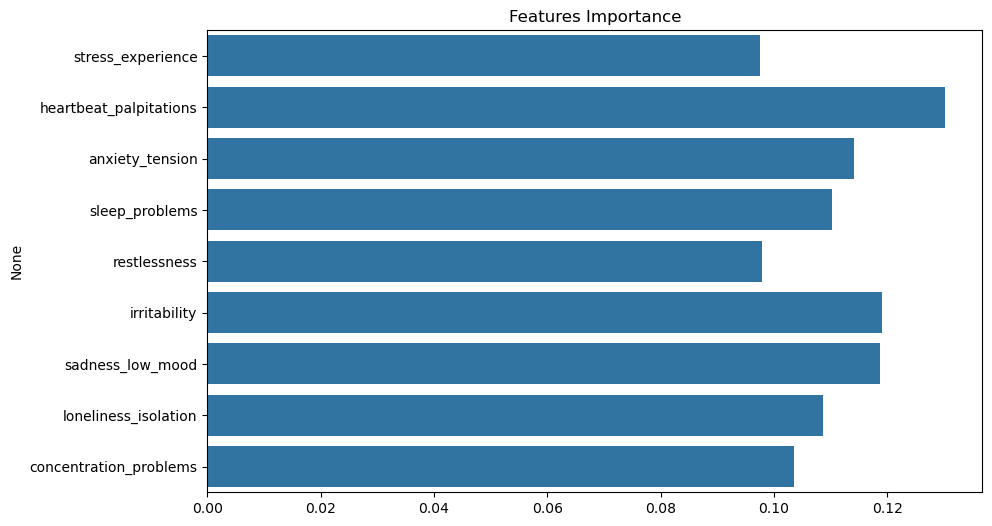

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
importances = model.feature_importances_
features = x.columns
plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features)
plt.title("Features Importance")
plt.show()

In [40]:
from sklearn.metrics import confusion_matrix
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[ 15   6   0]
 [  0 552   0]
 [  0   3  24]]


In [41]:
import pickle

# Save your trained model
pickle.dump(model, open("stress_model.pkl", "wb"))